In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize

`Path.cwd()` returns the current working directory as a Path object in Python.

# Import dataset

In [2]:
from pathlib import Path
current_dir = Path.cwd()
dataset_path = current_dir / "logistic_regression_overfit_dataset.csv"

In [3]:
data = np.loadtxt(f'{dataset_path}', delimiter=',', dtype=np.float64, skiprows=1)
X, y = data[:, :-1], data[:, -1].reshape((-1, 1))

In [4]:
X

array([[-0.695669, -0.729569],
       [-1.036592, -0.332115],
       [-0.572237,  1.014188],
       [-0.568855, -0.739609],
       [ 0.894696, -0.088914],
       [-0.768798,  0.488817],
       [-0.331146,  0.835288],
       [-0.691149, -0.932328],
       [-1.03537 ,  0.186064],
       [-0.094361, -0.939608],
       [ 0.89405 ,  0.623669],
       [-0.286193,  0.869614],
       [ 0.892549,  0.655711],
       [ 1.101388, -0.011786],
       [ 0.566601, -0.933514],
       [ 0.93618 ,  0.308312],
       [-0.274195,  1.094557],
       [ 0.52511 , -0.786522],
       [ 0.92005 , -0.224349],
       [ 0.373785,  0.883463],
       [-0.295653, -1.033838],
       [ 0.905116, -0.250486],
       [ 0.430049,  0.87637 ],
       [-0.818755, -0.508547],
       [ 0.611184, -0.874365],
       [-1.148195,  0.027636],
       [ 0.226114,  0.896402],
       [ 0.527139,  0.819409],
       [ 1.067962,  0.208533],
       [-0.449501, -0.847945],
       [-0.43    , -0.28    ],
       [ 0.17    ,  0.49    ],
       [

In [5]:
y

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

# Plot the data

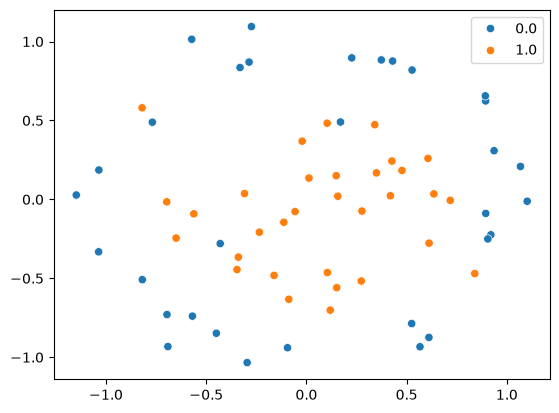

In [6]:
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y.flatten())
plt.show()

# The sigmoid function

$\sigma: \frac{1}{1+e^{-z}}$

In [7]:
def sigmoid(z):
    return 1 / (1+np.exp(-z))

# The cross entropy loss function

$$
J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}
\left[
y^{(i)}\log\left(h_\theta(x^{(i)})\right)
+
(1-y^{(i)})\log\left(1-h_\theta(x^{(i)})\right)
\right]

$$

In [8]:
def loss(theta, X, y):
    h = sigmoid(np.dot(X, theta)) # Hypothesis
    cost = -(np.sum(y * np.log(h)) +
             np.sum((1-y) * np.log(1-h))) / len(y)

    return cost

# The gradient

In [9]:
def grad(theta, X, y):
    h = sigmoid(np.dot(X, theta))
    grad = np.dot(X.T, (h-y)) / len(y)
    return grad

# The feature trick

In [10]:
def expand_feature(x1, x2, power=2):
    new_x = np.ones((x1.shape[0], 1))

    for i in range(1, power + 1): # The total power of the polynomial
        for j in range(i + 1):
            feature = (x1**(i-j) * x2**j).reshape(-1, 1)
            new_x = np.append(new_x, feature, axis=1)#Column

    return new_x

In [11]:
def predict(theta, X):
    return (sigmoid(np.dot(X, theta)) > 0.5).flatten()

# Gradient descent

$\theta \leftarrow \theta - \alpha \frac{1}{m} X^T(h-y)$

In [12]:
def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    costs = []

    for _ in range(num_iters):
        h = sigmoid(np.dot(X, theta))
        theta -= alpha * np.dot(X.T, (h - y)) / m
        costs.append(loss(theta, X, y))

    return theta, costs

# Implement Logistic Regression

In [13]:
def logistic_regression(X, y, power=2, alpha=0.01, num_iters=100):
    X = expand_feature(X[:, 0], X[:, 1], power=power)
    theta = np.zeros((X.shape[1], 1), dtype=np.float64)
    theta, costs = gradient_descent(X, y, theta, alpha, num_iters)
    predicted = predict(theta, X)
    return predicted, theta, costs


# Decide the polynomial power in the features, and the number of iterations

In [14]:
power, num_iters = 10, 20000
predicted, theta, costs = logistic_regression(X, y, power = power, alpha=0.6, num_iters=num_iters)

In [15]:
print('The accuracy is {:.2f} %'.format(sum(predicted == y.flatten()) / len(y) * 100))

The accuracy is 96.88 %


# Visualize the classifier

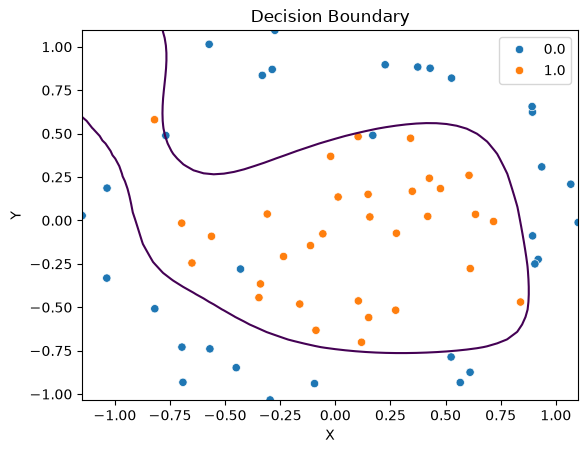

In [16]:
u = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 50)
# 50 Positions in x axis
v = np.linspace(np.min(X[:, 1]), np.max(X[:, 1]), 50)
# 50 Positions in y axis
z = np.zeros((len(u), len(v)))
# Every z[i,j] corresponds to a coordinate on the mesh

for i in range(len(u)):
    for j in range(len(v)):
        features = expand_feature(
            np.array([u[i]]),
            np.array([v[j]]),
            power=power
        )

        z[i, j] = np.dot(features, theta).item()

z = z.T

plt.contour(u, v, z, levels=[0])
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y.flatten())

plt.title("Decision Boundary")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# Now let's look at regularization

# Cost Function:
$$
J(\theta)
=
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i\log(h_i)
+
(1-y_i)\log(1-h_i)
\right]
+
\frac{\lambda}{m}
\sum_{j=1}^{n}\theta_j^2
$$

In [17]:
def cost_reg(theta, X, y, lam=0):
    h = sigmoid(np.dot(X, theta))
    theta1 = theta.copy()
    theta1[0] = 0

    cos = -(np.sum(y * np.log(h)) +
            np.sum((1 - y) * np.log(1 - h))) / len(y) \
          + lam * np.sum(theta1 * theta1) / len(y)

    return cos

# Regularization: Gradient

$$
\nabla J(\theta)
=
\frac{1}{m}
\left[
X^T(h-y)+2\lambda\theta'
\right]
$$

In [18]:
def grad_reg(theta, X, y, lam=0):
    h = sigmoid(np.dot(X, theta))
    theta1 = theta.copy()
    theta1[0] = 0
    grad = (np.dot(X.T, (h - y)) + 2 * lam * theta1) / len(y)
    return grad

# Regularization: Gradient Descent

In [19]:
def gradient_descent_reg(X, y, theta, alpha, lam=0, num_iters=100):
    m = len(y)
    costs = []

    for _ in range(num_iters):
        h = sigmoid(np.dot(X, theta))
        theta1 = theta.copy()
        theta1[0] = 0

        theta -= alpha * (np.dot(X.T, (h - y)) + 2 * lam * theta1) / m
        costs.append(cost_reg(theta, X, y))

    return theta, costs

# Regularization: Logistic Regression

In [20]:
def logistic_regression_reg(X, y, power=2, alpha=0.01, lam=0, num_iters=100):
    X = expand_feature(X[:, 0], X[:, 1], power=power)
    theta = np.zeros((X.shape[1], 1), dtype=np.float64)
    theta, costs = gradient_descent_reg(X, y, theta, alpha, lam, num_iters)
    predicted = predict(theta, X)
    return predicted, theta, costs

# Decide the polynomial feature, number of iterations, lambda

In [21]:
power, num_iters = 10, 20000
lam = 3
predicted, theta, costs = logistic_regression_reg(X, y, power = power, alpha=0.6, lam=lam, num_iters=num_iters)

In [22]:
print('The accuracy is {:.2f} %'.format(sum(predicted == y.flatten()) / len(y) * 100))

The accuracy is 93.75 %


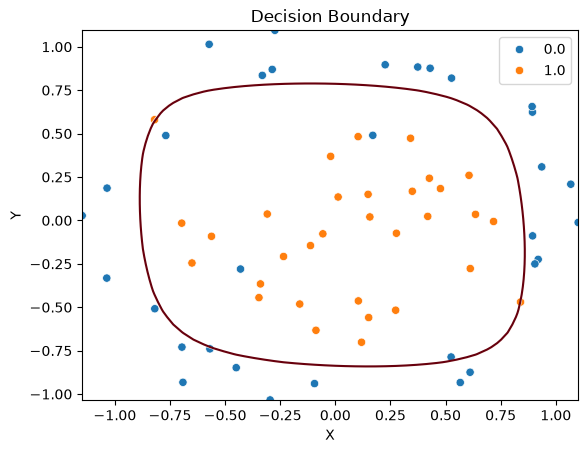

In [23]:
u = np.linspace(min(X[:, 0]), max(X[:, 0]), 50)
v = np.linspace(min(X[:, 1]), max(X[:, 1]), 50)

z = np.zeros((len(u), len(v)))

for i in range(len(u)):
    for j in range(len(v)):
        z[i, j] = np.dot(
            expand_feature(
                u[i].reshape(1, -1),
                v[j].reshape(1, -1),
                power=power
            ),
            theta
        ).item()

z = np.transpose(z)

plt.contour(u, v, z, [0, 0.01], cmap="Reds")
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y.flatten())
plt.title("Decision Boundary")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# You can play around the hyperparamters.

The higher the `power`, the more likely that overfitting will occur

The higher the  `lambda`, the greater the loss is end up with

Number of iterations, learning rate, feature dimensions, and regularization lambda are all important.